# 지연 위험도(정상/주의/위험) 분류 모델 — LightGBM / CatBoost / XGBoost / Random Forest 비교 및 튜닝

피처 선정(상관계수 R² 기반, 4개 모델 공용) → 이슈 단위 층화 분할 → LightGBM/CatBoost/XGBoost/
RandomForest 각각 학습 → 4개 모델 성능 비교 → MLflow 기반 하이퍼파라미터 튜닝 → 최적 모델 저장까지의
파이프라인을 함수로 감싸지 않고, 각 단계를 셀 단위로 라이브러리 함수를 직접 호출하며 실행합니다.
중간 결과(피처 후보/딕셔너리, 분할 결과, 클래스 분포, 피처 중요도, 성능 비교표, 혼동 행렬 등)는 각 단계
직후 셀에서 바로 확인할 수 있습니다.

튜닝 결과 가장 높은 검증 macro avg f1-score를 기록한 모델을 `delay_model.pkl`로 저장합니다. F2-score도 함께 확인합니다. 저장/로드
(`load_artifact`)와 실시간 추론(`predict_class_probabilities`, `proxy_deadline_for`)은 최적 모델 유형
(LightGBM/CatBoost/XGBoost/RandomForest)에 맞춰 동작합니다. 이 함수들은
`App/backend_fastapi/ml_delay_risk/services/delay_service.py`가 사용합니다.

학습 데이터는 `ml_delay_risk/models/mock_issue_dataset.py`가 만드는, 팀 Supabase 스키마
(tasks/milestones/task_checklists/task_comments/activities) 형태의 임의 생성(fake) 데이터입니다.
DB 접속이 필요 없어 노트북을 그대로 실행하면 바로 재현됩니다(seed 고정).


# Feature Descriptions (피처 설명 목록)

| 피처명 (Feature Name) | 설명 (Description) |
| :--- | :--- |
| `project_key` | 프로젝트 코드 (이슈 키 접두사, 예: JELLY) |
| `issuetype_name` | 이슈 유형 (Bug/Task/Improvement 등) |
| `priority_name` | 우선순위 (Blocker/Critical/Major/Minor/Trivial) |
| `reporter` | 이슈 등록자 (빈도 인코딩) |
| `is_subtask` | 하위 작업(subtask) 여부 |
| `milestone_id` | 연결된 마일스톤 ID (없으면 결측 — 학습 피처로는 안 쓰고 참고용 식별자) |
| `has_milestone` | 마일스톤에 연결돼 있는지 여부 |
| `milestone_unresolved` | 연결된 마일스톤이 아직 미완료 상태인지 여부 |
| `num_subtasks` | 하위 작업 개수 |
| `num_unresolved_subtasks` | 하위 작업 중 미해결 개수 |
| `num_components` | 소속 컴포넌트(모듈) 개수 |
| `num_fixversions` | 목표 릴리즈 버전 개수 |
| `has_released_fixversion` | 목표 릴리즈 버전 중 이미 배포된 것이 있는지 여부 |
| `num_versions` | 영향받는 버전 개수 |
| `has_original_estimate` | 최초 예상 소요시간(estimate)이 설정되어 있는지 여부 |
| `original_estimate_seconds` | 최초 예상 소요시간(초 단위) |
| `num_issuelinks_total` | 다른 이슈와의 연관관계 총 개수 |
| `num_blocked_by_links` | '~에 의해 막힘' 관계 개수 |
| `num_unresolved_blockers` | 블로커 이슈 중 아직 해결되지 않은 것의 개수 |
| `created_day_of_week` | 생성 요일 (0=월요일 ~ 6=일요일) |
| `created_hour` | 생성 시각 (0~23시) |
| `summary_length` | 이슈 제목 길이 (문자 수, 복잡도 근사치) |
| `status_at_cutoff` | cutoff 시점의 상태 (Open/In Progress/Blocked 등) |
| `assignee_at_cutoff` | cutoff 시점의 담당자 (빈도 인코딩) |
| `num_events_before_cutoff` | cutoff 이전 변경 이력(이벤트) 총 개수 |
| `num_status_changes` | 상태 변경 횟수 |
| `num_assignee_changes` | 담당자 변경(재배정) 횟수 |
| `num_reopens` | 상태가 Open/Reopened로 되돌아간 횟수 |
| `hours_in_current_status` | 마지막 상태 변경 이후 ~ cutoff까지 경과한 시간 |
| `blocked_hours_before_cutoff` | 블로커 상태에 머문 누적 시간 |
| `num_comments_before_cutoff` | cutoff 이전 댓글 수 |
| `num_unique_commenters` | 댓글을 남긴 고유 인원 수 |
| `hours_since_last_comment` | 마지막 댓글로부터 ~ cutoff까지 경과 시간 |
| `num_worklog_entries` | 작업 기록(worklog) 건수 (봇 계정 제외) |
| `num_unique_workers` | 실제 작업한 고유 인원 수 |
| `time_spent_seconds_before_cutoff` | cutoff까지 누적 투입 시간 (초, 봇 제외) |
| `progress_ratio_at_cutoff` | 진행률 (누적 투입시간 ÷ 최초 예상시간) |
| `elapsed_hours_at_cutoff` | 이슈 생성 후 ~ cutoff까지 경과 시간 (절대값, 시간 단위) |
| `activity_count_recent_window` | 최근 N일간 활동(댓글+상태변경+작업기록) 합계 |
| `is_self_assigned` | 보고자와 담당자가 동일 인물인지 여부 |
| `snapshot_offset_days` | 스냅샷 시점 (이슈 생성 후 며칠째인지) |

## 1. 환경 설정 — 노트북 위치와 무관하게 backend_fastapi를 찾아 `sys.path`에 추가

In [106]:
import sys
from pathlib import Path


def _find_backend_fastapi_root() -> Path:
    # VS Code Jupyter 확장은 현재 열린 노트북의 절대경로를 __vsc_ipynb_file__ 전역변수로 제공한다.
    # 이게 없는 환경(JupyterLab 등)에서는 커널의 현재 작업 디렉터리(cwd)로 대체한다.
    notebook_path = globals().get("__vsc_ipynb_file__")
    search_start = Path(notebook_path).resolve().parent if notebook_path else Path.cwd()

    # 노트북이 ml_delay_risk/ 바로 아래에 있든 models/ 등 하위 폴더로
    # 옮겨지든 상관없이 상위 폴더를 훑어 backend_fastapi(=ml_delay_risk의
    # 부모)를 찾는다. cwd에 의존하는 방식(Path.cwd().parent)은 노트북 프론트엔드마다
    # 커널 작업 디렉터리가 달라 깨지기 쉬워 사용하지 않는다.
    for candidate in [search_start, *search_start.parents]:
        if (candidate / "ml_delay_risk").is_dir():
            return candidate
        if (candidate / "backend_fastapi" / "ml_delay_risk").is_dir():
            return candidate / "backend_fastapi"
        if (candidate / "App" / "backend_fastapi" / "ml_delay_risk").is_dir():
            return candidate / "App" / "backend_fastapi"

    raise RuntimeError(
        f"'{search_start}' 및 상위 폴더에서 ml_delay_risk 패키지를 찾지 못했습니다.\n"
        "노트북이 backend_fastapi 프로젝트 안에 있는지 확인하거나, 아래처럼 경로를 직접 추가하세요:\n"
        '    sys.path.insert(0, r"D:\\...\\backend_fastapi")'
    )


BACKEND_FASTAPI_ROOT = _find_backend_fastapi_root()
if str(BACKEND_FASTAPI_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_FASTAPI_ROOT))

print("BACKEND_FASTAPI_ROOT =", BACKEND_FASTAPI_ROOT)
print("sys.path[0] =", sys.path[0])


BACKEND_FASTAPI_ROOT = D:\AIproject\project\Team\work-flow\App\backend_fastapi
sys.path[0] = D:\AIproject\project\Team\work-flow\App\backend_fastapi


## 2. Imports

In [107]:
from __future__ import annotations

import logging
import os
import threading
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Optional

import joblib
import lightgbm as lgb
import mlflow
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 설치된 폰트 중 한글 폰트가 있을 때만 지정한다. 리스트로 지정하면 matplotlib가
# 글자 단위로 각 후보 폰트를 확인하며 없는 폰트마다 findfont 경고를 반복 출력하므로,
# font_manager로 실제 설치 여부를 미리 확인해 존재하는 폰트 하나만 설정한다.
# 아무 것도 없으면(Docker/Linux 등) 건드리지 않고 matplotlib 기본 폰트를 그대로 쓴다
# (한글 라벨은 tofu로 깨져 보일 수 있지만 경고는 나지 않는다).
import matplotlib.font_manager as fm

_installed_fonts = {f.name for f in fm.fontManager.ttflist}
_korean_font = next(
    (name for name in ("Malgun Gothic", "NanumGothic", "AppleGothic") if name in _installed_fonts),
    None,
)
if _korean_font:
    plt.rcParams["font.family"] = _korean_font
plt.rcParams["axes.unicode_minus"] = False  # 위 폰트 사용 시 마이너스 기호 깨짐 방지
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, fbeta_score
from sklearn.model_selection import train_test_split

from ml_delay_risk.models.feature_engineering import RISK_CLASS_NAMES
from ml_delay_risk.config import get_settings

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)


## 3. 상수 정의

- `CATEGORICAL_COLUMNS`: LightGBM 네이티브 범주형 처리 대상 (저카디널리티).
- `FREQUENCY_ENCODED_COLUMNS`: 담당자/보고자처럼 카디널리티가 높은 컬럼은 빈도 인코딩으로 처리.
- `NON_FEATURE_COLUMNS`: 학습에 쓰지 않는 부기(bookkeeping) 컬럼. `proxy_deadline_hours`는
  issuetype/priority로 이미 결정되는 중복 정보라 피처에서 제외합니다.


In [108]:
# <데이터 누수 방지>
# (해결)
# LEAKY_FEATURE_COLUMNS를 NON_FEATURE_COLUMNS에 재합류 (cell 6)
# — elapsed_ratio_at_cutoff, blocked_ratio_at_cutoff, imbalance_index_at_cutoff, hours_until_deadline_at_cutoff
# 4개를 다시 피처에서 제외.

# (문제 원인)
# elapsed_ratio_at_cutoff / blocked_ratio_at_cutoff / imbalance_index_at_cutoff는
# mock_issue_dataset.py가 risk_class(정상/주의/위험)를 정할 때 목표로 삼는 바로 그
# 값들이다(라벨을 이 비율들이 특정 구간에 들어가도록 시나리오를 만들어 배정한다 —
# classify_risk() 규칙을 직접 호출하진 않지만 사실상 동일한 정보). hours_until_deadline_
# at_cutoff는 proxy_deadline_hours - elapsed_hours_at_cutoff로 역산 가능해 마찬가지다.
# 피처로 남겨두면 모델이 패턴을 학습하는 대신 라벨링 규칙식을 그대로 베껴버린다(타겟 누수).
LEAKY_FEATURE_COLUMNS = [
    "elapsed_ratio_at_cutoff",
    "blocked_ratio_at_cutoff",
    "imbalance_index_at_cutoff",
    "hours_until_deadline_at_cutoff",
]

# <Supabase 실서비스 스키마와 피처 정합성 확보>
# 학습(mock_issue_dataset.py)과 실제 서비스(delay_service.py)가 이제 둘 다
# delay_service.build_feature_row를 그대로 호출해 피처를 만든다. 이 함수는 Supabase
# 스키마(tasks/milestones/task_checklists/task_comments/activities)에 대응 개념이 전혀
# 없는 아래 컬럼들을 항상 고정값(0/False/"unknown" 등)으로 채워서 반환한다 — 학습이든
# 실시간 추론이든 항상 상수이므로, 후보로 남겨두면 예측력에 전혀 기여하지 못하고
# 오히려 더 유용한 다른 피처가 선택될 기회를 뺏는다. (has_original_estimate가 대표적
# 사례 — Jira로 학습하던 시절엔 중요도 1위(39%)였지만 Supabase tasks 테이블에는
# 예상 소요시간 컬럼이 없어 항상 False/0으로 들어간다.)
SUPABASE_UNAVAILABLE_COLUMNS = [
    # reporter/작성자 개념 없음 (tasks에는 assignee_id만 있고 생성자 컬럼이 없음)
    "reporter",
    "is_self_assigned",
    # 하위 작업(subtask) 관계 없음 — task_checklists(체크리스트 항목)로
    # num_subtasks/num_unresolved_subtasks를 이미 근사해서 쓰고 있으므로 그건 유지.
    "is_subtask",
    # 릴리즈/버전/컴포넌트 관리 개념 없음
    "num_components",
    "num_fixversions",
    "has_released_fixversion",
    "num_versions",
    # 예상 소요시간(estimate) 컬럼 없음
    "has_original_estimate",
    "original_estimate_seconds",
    # 이슈 링크/블로커 관계 테이블 없음 (블로커 '상태' 자체는 status_at_cutoff /
    # blocked_hours_before_cutoff로 이미 반영되므로 제외 대상이 아님)
    "num_issuelinks_total",
    "num_blocked_by_links",
    "num_unresolved_blockers",
    # worklog/시간기록 테이블 없음
    "num_worklog_entries",
    "num_unique_workers",
    "time_spent_seconds_before_cutoff",
    # activities 테이블은 "업무 변경"을 뭉뚱그린 이벤트만 남겨서 상태 변경과
    # 담당자 변경을 구분할 수 없다 (num_events_before_cutoff로 총합만 근사해서 쓴다).
    "num_status_changes",
    "num_assignee_changes",
    "num_reopens",
]

NON_FEATURE_COLUMNS = [
    "issue_key",
    "created",
    "risk_class",
    "proxy_deadline_hours",
    # 몇 번 마일스톤인지 식별하는 값일 뿐 예측에 쓸 피처가 아니다(연결 여부/미해결 여부는
    # has_milestone/milestone_unresolved로 이미 반영됨). 카디널리티도 높고 새 프로젝트의
    # 마일스톤 ID는 학습 때 못 본 값이라 일반화도 안 된다.
    "milestone_id",
    # db.py의 _TASKS_QUERY가 실제로 읽는 원본 Supabase 컬럼을 그대로 보존하는 참고용
    # 필드들 — title은 자유 텍스트, 나머지는 원시 타임스탬프라 그 자체로는 학습 피처가
    # 아니다(요약/경과/마일스톤 정보는 summary_length/elapsed_hours_at_cutoff/
    # has_milestone 등으로 이미 피처화돼 있음).
    "title",
    "due_date",
    "updated_at",
    "milestone_due_date",
] + LEAKY_FEATURE_COLUMNS + SUPABASE_UNAVAILABLE_COLUMNS

# 후보 피처들의 의미 설명 (선정 결과를 사람이 읽을 수 있게 출력할 때 사용).
# feature_engineering.py의 build_static_features/build_dynamic_features가 만드는
# 필드와 1:1로 대응한다.
FEATURE_DESCRIPTIONS: dict[str, str] = {
    "project_key": "프로젝트 코드 (이슈 키 접두사, 예: JELLY)",
    "issuetype_name": "이슈 유형 (Bug/Task/Improvement 등)",
    "priority_name": "우선순위 (Blocker/Critical/Major/Minor/Trivial)",
    "reporter": "이슈 등록자 (빈도 인코딩)",
    "is_subtask": "하위 작업(subtask) 여부",
    "milestone_id": "연결된 마일스톤 ID (참고용 식별자, 학습 피처 아님)",
    "title": "업무 제목 원문 (참고용, 학습 피처 아님 — summary_length로 이미 피처화됨)",
    "due_date": "업무 마감일 원본 타임스탬프 (참고용, 학습 피처 아님)",
    "updated_at": "업무 마지막 수정 시각 원본 타임스탬프 (참고용, 학습 피처 아님)",
    "milestone_due_date": "연결된 마일스톤의 마감일 원본 타임스탬프 (참고용, 학습 피처 아님)",
    "has_milestone": "마일스톤에 연결돼 있는지 여부",
    "milestone_unresolved": "연결된 마일스톤이 아직 미완료 상태인지 여부",
    "num_subtasks": "하위 작업 개수",
    "num_unresolved_subtasks": "하위 작업 중 미해결 개수",
    "num_components": "소속 컴포넌트(모듈) 개수",
    "num_fixversions": "목표 릴리즈 버전 개수",
    "has_released_fixversion": "목표 릴리즈 버전 중 이미 배포된 것이 있는지 여부",
    "num_versions": "영향받는 버전 개수",
    "has_original_estimate": "최초 예상 소요시간(estimate)이 설정되어 있는지 여부",
    "original_estimate_seconds": "최초 예상 소요시간(초 단위)",
    "num_issuelinks_total": "다른 이슈와의 연관관계 총 개수",
    "num_blocked_by_links": "'~에 의해 막힘' 관계 개수",
    "num_unresolved_blockers": "블로커 이슈 중 아직 해결되지 않은 것의 개수",
    "created_day_of_week": "생성 요일 (0=월요일 ~ 6=일요일)",
    "created_hour": "생성 시각 (0~23시)",
    "summary_length": "이슈 제목 길이 (문자 수, 복잡도 근사치)",
    "status_at_cutoff": "cutoff 시점의 상태 (Open/In Progress/Blocked 등)",
    "assignee_at_cutoff": "cutoff 시점의 담당자 (빈도 인코딩)",
    "num_events_before_cutoff": "cutoff 이전 변경 이력(이벤트) 총 개수",
    "num_status_changes": "상태 변경 횟수",
    "num_assignee_changes": "담당자 변경(재배정) 횟수",
    "num_reopens": "상태가 Open/Reopened로 되돌아간 횟수",
    "hours_in_current_status": "마지막 상태 변경 이후 ~ cutoff까지 경과한 시간",
    "blocked_hours_before_cutoff": "블로커 상태에 머문 누적 시간",
    "num_comments_before_cutoff": "cutoff 이전 댓글 수",
    "num_unique_commenters": "댓글을 남긴 고유 인원 수",
    "hours_since_last_comment": "마지막 댓글로부터 ~ cutoff까지 경과 시간",
    "num_worklog_entries": "작업 기록(worklog) 건수 (봇 계정 제외)",
    "num_unique_workers": "실제 작업한 고유 인원 수",
    "time_spent_seconds_before_cutoff": "cutoff까지 누적 투입 시간 (초, 봇 제외)",
    "progress_ratio_at_cutoff": "진행률 (누적 투입시간 ÷ 최초 예상시간)",
    "elapsed_hours_at_cutoff": "이슈 생성 후 ~ cutoff까지 경과 시간 (절대값, 시간 단위)",
    "activity_count_recent_window": "최근 N일간 활동(댓글+상태변경+작업기록) 합계",
    "is_self_assigned": "보고자와 담당자가 동일 인물인지 여부",
    "snapshot_offset_days": "스냅샷 시점 (이슈 생성 후 며칠째인지)",
}


## 3b. `_RUN_TRAINING_CELLS` — 학습/EDA 셀 실행 여부 플래그

아래부터 등장하는 `if _RUN_TRAINING_CELLS:` 블록(학습 실행, 피처 중요도 시각화, 혼동 행렬 등)은
노트북을 직접 열어 대화형으로 실행할 때만 돌아야 하고, `_notebook_runtime.load()`가
`load_artifact`/`predict_class_probabilities` 등 함수만 가져다 쓸 때는 실행되면 안 된다.

Jupyter는 노트북 커널의 `__name__`을 기본적으로 `"__main__"`으로 설정하므로, 아래 셀에서
직접 실행 여부를 판별한다. `_notebook_runtime.load(run_main=True)`(예: `train.py`)가
이 값을 미리 `True`로 주입해 준 경우에는 그 값을 그대로 쓴다.


In [109]:
_RUN_TRAINING_CELLS = globals().get("_RUN_TRAINING_CELLS", __name__ == "__main__")


In [110]:
if _RUN_TRAINING_CELLS:
    print(f"FEATURE_DESCRIPTIONS 딕셔너리 — 총 {len(FEATURE_DESCRIPTIONS)}개 컬럼 설명")
    display(pd.DataFrame(FEATURE_DESCRIPTIONS.items(), columns=["feature", "description"]))


FEATURE_DESCRIPTIONS 딕셔너리 — 총 45개 컬럼 설명


,feature,description
0,project_key,"프로젝트 코드 (이슈 키 접두사, 예: JELLY)"
1,issuetype_name,이슈 유형 (Bug/Task/Improvement 등)
2,priority_name,우선순위 (Blocker/Critical/Major/Minor/Trivial)
3,reporter,이슈 등록자 (빈도 인코딩)
4,is_subtask,하위 작업(subtask) 여부
5,milestone_id,"연결된 마일스톤 ID (참고용 식별자, 학습 피처 아님)"
6,title,"업무 제목 원문 (참고용, 학습 피처 아님 — summary_length로 이미 피..."
7,due_date,"업무 마감일 원본 타임스탬프 (참고용, 학습 피처 아님)"
8,updated_at,"업무 마지막 수정 시각 원본 타임스탬프 (참고용, 학습 피처 아님)"
9,milestone_due_date,"연결된 마일스톤의 마감일 원본 타임스탬프 (참고용, 학습 피처 아님)"


## 4. 모델 아티팩트 정의 / 저장·로드 / 실시간 추론 함수 (프로덕션 코드에서 import)

`ModelArtifact`(학습된 booster와, 추론 시 동일하게 재현해야 하는 인코딩 맵·Proxy Deadline 조회
테이블을 함께 묶은 것), 저장/로드 함수, 실시간 추론 함수(`predict_class_probabilities`,
`proxy_deadline_for`)는 `ml_delay_risk/models/delay_model.py`에 있습니다. 프로덕션 코드
(`routers/delay_router.py`, `services/delay_service.py`)가 이 노트북을 파싱/exec()하지 않고
평범한 모듈로 바로 import할 수 있도록 분리했습니다. 이 노트북은 아래에서 그 모듈을 import해서
학습 파이프라인에 사용합니다 (재정의하지 않으므로 정의는 한 곳에만 존재합니다).

In [111]:
from ml_delay_risk.models.delay_model import (
    CATEGORICAL_COLUMNS,
    FREQUENCY_ENCODED_COLUMNS,
    NUM_CLASSES,
    ModelArtifact,
    _save_artifact,
    load_artifact,
    predict_class_probabilities,
    proxy_deadline_for,
)


## 7. 학습 실행 — 피처 선정부터 4개 모델 학습까지

가짜 Supabase 데이터셋(`mock_issue_dataset.py`)으로 학습 데이터를 구성한 뒤, 아래 셀들이
피처 중요도 분석 → 학습/검증 분할 → LightGBM/CatBoost/XGBoost/RandomForest 학습 → 평가까지의
전 과정을 각 단계별로 라이브러리 함수를 셀에서 직접 호출하며 순서대로 실행합니다.

`mock_issue_dataset.build_training_dataframe`은 `ml_delay_risk/models/mock_issue_dataset.py`에
정의돼 있습니다. 팀 Supabase 스키마(tasks/milestones/task_checklists/task_comments/activities)
형태의 임의 생성 데이터를 만들고, 실제 서비스가 쓰는 `delay_service.build_feature_row`를 학습에도
그대로 재사용해 피처 계약을 일치시킵니다(train/serve skew 방지). DB 접속이 필요 없어 노트북을
그대로 실행하면 바로 재현됩니다.

`limit` 파라미터로 업무 수(정상/주의/위험 균형 샘플링 전 목표치)를 조절할 수 있습니다. 운영에서는
노트북 대신 `python -m ml_delay_risk.train`을 사용하세요.


In [113]:
"""
[target]업무 지연 위험도 3단계:
    Class 0 (정상): 마감일(Proxy Deadline) 이내에서 순항 중.
    Class 1 (주의): 마감일 이내지만 진행률이 저조하거나 블로커 상태에 짧게 머묾.
    Class 2 (위험): 마감일을 초과했거나, 블로커 상태에 장기간 머물러 활동이 정지(Silent).
"""
# <주피터 노트북 모듈화 - _notebook_runtime.py>
# _RUN_TRAINING_CELLS: 대화형 Jupyter에서 직접 실행할 때는 True(아래 새로 추가된 셀에서
# __name__ == "__main__"으로 판정), _notebook_runtime.load()가 함수 정의부만 가져다 쓸
# 때는 False. 학습/추론/탐색처럼 직접 실행되는 셀을 if _RUN_TRAINING_CELLS: 블록 안에 넣는다.
# (예전엔 __name__ == "__main__"을 직접 검사했지만, ModelArtifact 같은 클래스가 같은
# 노트북에서 정의되면 그 클래스의 __module__도 "__main__"이 되어 버려 joblib으로 저장한
# 모델을 다른 프로세스(FastAPI 서버)에서 로드할 때 피클이 깨지는 문제가 있어 이 플래그로 바꿨다.)
if _RUN_TRAINING_CELLS:
    from ml_delay_risk.models.mock_issue_dataset import build_training_dataframe

    # <균형 샘플링 — 정상/주의/위험 동일 개수>
    # (적용) mock_issue_dataset.build_training_dataframe이 라벨(정상/주의/위험)을 먼저
    # 동일 개수로 정한 뒤 그 라벨에 맞는 시나리오로 데이터를 생성하므로, 반환된 df는 항상
    # 3클래스가 정확히 균형이다(뒤 SMOTE 단계는 사실상 no-op으로 안전망 역할만 한다).

    # train.py에서 --limit을 지정하면 그 개수만큼(3의 배수로 맞춰 균형 샘플링) 만든다.
    # train.py가 `_TRAIN_LIMIT`을 미리 넣어주면 그 값을 쓰고, 노트북에서 직접 실행할 땐
    # 4500이 기본값(정상/주의/위험 각 1500건).
    limit = globals().get("_TRAIN_LIMIT", 4500)
    df, proxy_deadline_map, global_median = build_training_dataframe(limit=limit)
    if df.empty:
        raise SystemExit("학습 데이터가 비어 있습니다 — mock_issue_dataset.build_training_dataframe 반환값을 확인하세요.")


In [114]:
if _RUN_TRAINING_CELLS:
    # <임포트/생성 직후 데이터셋 시각화>
    # 피처 선정으로 축소되기 이전, 임포트 직후의 전체 후보 피처와 타겟(risk_class)을 확인한다.
    print("데이터셋 생성 완료 — shape:", df.shape)
    display(df.head())
    display(df.dtypes.rename("dtype"))


데이터셋 생성 완료 — shape: (4500, 47)


,issue_key,project_key,issuetype_name,priority_name,reporter,is_subtask,has_parent,parent_unresolved,num_subtasks,num_unresolved_subtasks,...,progress_ratio_at_cutoff,elapsed_hours_at_cutoff,elapsed_ratio_at_cutoff,hours_until_deadline_at_cutoff,imbalance_index_at_cutoff,activity_count_recent_window,is_self_assigned,snapshot_offset_days,created,risk_class
0,TASK-1,P9,deliverable,high,unknown,False,False,False,3,0,...,1.000000,2045.136679,1.059349,-114.577245,0.059349,0,False,85.214028,2026-04-26 03:51:47.954921,위험
1,TASK-2,P4,qa,high,unknown,False,True,True,0,0,...,NaN,2466.348231,0.735666,886.190033,NaN,1,False,102.764510,2026-04-08 14:39:06.367828,주의
2,TASK-3,P11,security,low,unknown,False,True,True,4,1,...,0.750000,1630.580313,0.745773,555.850301,-0.004227,2,False,67.940846,2026-05-13 10:25:10.873635,정상
3,TASK-4,P3,docs,medium,unknown,False,True,True,1,1,...,0.000000,1704.094992,0.516767,1593.516155,0.516767,3,False,71.003958,2026-05-10 08:54:18.028972,위험
4,TASK-5,P11,ux-ui,medium,unknown,False,False,False,3,1,...,0.666667,2457.212142,0.769247,737.094791,0.102581,2,False,102.383839,2026-04-08 23:47:16.289959,주의


issue_key                                   object
project_key                                 object
issuetype_name                              object
priority_name                               object
reporter                                    object
is_subtask                                    bool
has_parent                                    bool
parent_unresolved                             bool
num_subtasks                                 int64
num_unresolved_subtasks                      int64
num_components                               int64
num_fixversions                              int64
has_released_fixversion                       bool
num_versions                                 int64
has_original_estimate                         bool
original_estimate_seconds                    int64
num_issuelinks_total                         int64
num_blocked_by_links                         int64
num_unresolved_blockers                      int64
created_day_of_week            

In [115]:
if _RUN_TRAINING_CELLS:
    df["risk_class"].value_counts().sort_index()


In [116]:
if _RUN_TRAINING_CELLS:
    # <타겟 컬럼 인코딩 — 문자열('정상'/'주의'/'위험') -> 정수(0/1/2)>
    # mock_issue_dataset.build_training_dataframe()이 만드는 risk_class는 사람이 읽기 쉬운
    # 문자열이지만, 아래 파이프라인은 정수 코드를 전제로 짜여 있다:
    #   - 다음 섹션의 피처 선정(상관계수 R²)이 risk_class와의 상관계수를 직접 계산
    #   - LightGBM objective="multiclass"는 라벨이 반드시 0~(num_class-1) 정수여야 함
    #   - 프로덕션 계약(delay_router.py/task_delay_service.py, ModelArtifact)도 클래스
    #     인덱스 0/1/2 -> NORMAL/CAUTION/DANGER를 전제로 함
    # RISK_CLASS_NAMES({0:"정상",1:"주의",2:"위험"})의 역매핑으로 여기서 한 번만 변환해두면
    # 이후 셀(피처 선정/분할/SMOTE/4개 모델 학습/MLflow 튜닝/저장)은 손대지 않고 그대로 쓴다.
    risk_class_code_by_label = {name: code for code, name in RISK_CLASS_NAMES.items()}
    unmapped = sorted(set(df["risk_class"].unique()) - set(risk_class_code_by_label))
    if unmapped:
        raise ValueError(f"RISK_CLASS_NAMES에 없는 risk_class 값이 있습니다: {unmapped}")
    df["risk_class"] = df["risk_class"].map(risk_class_code_by_label).astype(int)


In [117]:
if _RUN_TRAINING_CELLS:
    # 시간(created) 기준 정렬 — 이후 이슈 단위 분할과 무관하게, 데이터 확인 시 시간 순서를 보장.
    df = df.sort_values("created").reset_index(drop=True)

    # 학습에 쓰지 않는 부기 컬럼(NON_FEATURE_COLUMNS)을 제외한 나머지가 피처 후보.
    candidate_features = [c for c in df.columns if c not in NON_FEATURE_COLUMNS]
    print(f"피처 후보 {len(candidate_features)}개: {candidate_features}")


피처 후보 22개: ['project_key', 'issuetype_name', 'priority_name', 'has_parent', 'parent_unresolved', 'num_subtasks', 'num_unresolved_subtasks', 'created_day_of_week', 'created_hour', 'summary_length', 'status_at_cutoff', 'assignee_at_cutoff', 'num_events_before_cutoff', 'hours_in_current_status', 'blocked_hours_before_cutoff', 'num_comments_before_cutoff', 'num_unique_commenters', 'hours_since_last_comment', 'progress_ratio_at_cutoff', 'elapsed_hours_at_cutoff', 'activity_count_recent_window', 'snapshot_offset_days']


In [118]:
if _RUN_TRAINING_CELLS:
    # <컬럼을 딕셔너리 형태로 담음 — freq_maps>
    # 피처 중요도 프로브용으로, 전체 데이터 기준 "값 -> 등장 횟수" 딕셔너리를 만든다.
    freq_maps = {
        col: df[col].value_counts().to_dict()
        for col in FREQUENCY_ENCODED_COLUMNS
        if col in df.columns
    }
    print(f"빈도 인코딩 딕셔너리(freq_maps) 생성 완료 — 대상 컬럼: {list(freq_maps.keys())}")
    for col, mapping in freq_maps.items():
        print(f"  · {col}: 고유값 {len(mapping)}개 (상위 5개: {dict(list(mapping.items())[:5])})")


빈도 인코딩 딕셔너리(freq_maps) 생성 완료 — 대상 컬럼: ['reporter', 'assignee_at_cutoff']
  · reporter: 고유값 1개 (상위 5개: {'unknown': 4500})
  · assignee_at_cutoff: 고유값 72개 (상위 5개: {'unassigned': 213, '1': 107, '4': 95, '71': 94, '69': 91})


In [119]:
if _RUN_TRAINING_CELLS:
    # 피처 선정(상관계수 계산)용 인코딩 — 실제 학습(train_df/test_df)과는 별개로,
    # 전체 데이터를 그대로 인코딩한다. 모델을 학습시키지 않고 상관계수만 계산하므로
    # (아래 참고) 클래스 가중치는 필요 없다.
    encoded_df = df.copy()
    for col in FREQUENCY_ENCODED_COLUMNS:
        if col in encoded_df.columns:
            encoded_df[col] = encoded_df[col].map(freq_maps.get(col, {})).fillna(0).astype(int)
    for col in CATEGORICAL_COLUMNS:
        if col in encoded_df.columns:
            encoded_df[col] = encoded_df[col].astype("category")

    print(f"피처 선정용 인코딩 완료 — encoded_df shape: {encoded_df.shape}")


피처 선정용 인코딩 완료 — encoded_df shape: (4500, 47)


In [120]:
if _RUN_TRAINING_CELLS:
    # <공용 피처 선정 — 상관계수(R²) 기반, LightGBM/CatBoost/XGBoost/RandomForest 4개 모델 공용>
    # 각 모델이 따로 피처 중요도를 재면 "어떤 모델이 더 유리한 피처를 골랐는가"가 알고리즘
    # 자체 비교에 섞여 들어가므로, 모델에 의존하지 않는 상관계수로 한 번만 선정해 4개
    # 모델이 완전히 같은 selected_features를 쓰게 한다.
    #
    # CATEGORICAL_COLUMNS(issuetype_name/priority_name/project_key/status_at_cutoff)는
    # 순서가 없는 명목형이라, 임의의 정수 코드로 그냥 상관계수를 내면 코드 순서(예: 알파벳
    # 순)에 따라 왜곡된다. 원-핫으로 펼쳐 더미 컬럼별 상관계수를 구한 뒤, 같은 원본 컬럼에서
    # 나온 더미들의 R²를 합산해서 원본 컬럼 하나의 설명력으로 되돌린다.
    numeric_candidate_features = [c for c in candidate_features if c not in CATEGORICAL_COLUMNS]
    r2_by_feature: dict[str, float] = {}

    for col in numeric_candidate_features:
        r = encoded_df[col].corr(encoded_df["risk_class"])
        r2_by_feature[col] = 0.0 if pd.isna(r) else r ** 2

    nominal_candidate_columns = [c for c in CATEGORICAL_COLUMNS if c in candidate_features]
    if nominal_candidate_columns:
        nominal_dummies = pd.get_dummies(encoded_df[nominal_candidate_columns], columns=nominal_candidate_columns)
        for source_col in nominal_candidate_columns:
            dummy_cols = [c for c in nominal_dummies.columns if c.startswith(f"{source_col}_")]
            dummy_r2_total = 0.0
            for dummy_col in dummy_cols:
                r = nominal_dummies[dummy_col].corr(encoded_df["risk_class"])
                dummy_r2_total += 0.0 if pd.isna(r) else r ** 2
            r2_by_feature[source_col] = dummy_r2_total

    r2_series = pd.Series(r2_by_feature)
    r2_pct = r2_series / r2_series.sum() * 100 if r2_series.sum() > 0 else r2_series

    feature_importance_report = pd.DataFrame(
        {"feature": r2_series.index, "r2": r2_series.values, "r2_pct": r2_pct.values}
    ).sort_values("r2_pct", ascending=False).reset_index(drop=True)

    importance_threshold = 0.01
    selected_features = feature_importance_report.loc[
        feature_importance_report["r2_pct"] / 100 >= importance_threshold, "feature"
    ].tolist()

    print(
        f"피처 선정(상관계수 R² 기반): 후보 {len(candidate_features)}개 중 {len(selected_features)}개 선정 "
        f"(기준: R² 비중 {importance_threshold * 100:.1f}% 이상) — 4개 모델 공용"
    )
    display(feature_importance_report)


피처 선정(상관계수 R² 기반): 후보 22개 중 8개 선정 (기준: R² 비중 1.0% 이상) — 4개 모델 공용


,feature,r2,r2_pct
0,status_at_cutoff,0.313818,38.558354
1,blocked_hours_before_cutoff,0.203979,25.062584
2,hours_since_last_comment,0.121973,14.986616
3,activity_count_recent_window,0.064141,7.880959
4,num_comments_before_cutoff,0.036793,4.520654
5,hours_in_current_status,0.027156,3.336628
6,num_events_before_cutoff,0.018321,2.251020
7,num_unique_commenters,0.015624,1.919685
8,project_key,0.005785,0.710837
9,issuetype_name,0.002209,0.271382



선정된 피처 8개 설명 (R² 비중 내림차순):
  - status_at_cutoff (R² 비중 38.6%): cutoff 시점의 상태 (Open/In Progress/Blocked 등)
  - blocked_hours_before_cutoff (R² 비중 25.1%): 블로커 상태에 머문 누적 시간
  - hours_since_last_comment (R² 비중 15.0%): 마지막 댓글로부터 ~ cutoff까지 경과 시간
  - activity_count_recent_window (R² 비중 7.9%): 최근 N일간 활동(댓글+상태변경+작업기록) 합계
  - num_comments_before_cutoff (R² 비중 4.5%): cutoff 이전 댓글 수
  - hours_in_current_status (R² 비중 3.3%): 마지막 상태 변경 이후 ~ cutoff까지 경과한 시간
  - num_events_before_cutoff (R² 비중 2.3%): cutoff 이전 변경 이력(이벤트) 총 개수
  - num_unique_commenters (R² 비중 1.9%): 댓글을 남긴 고유 인원 수


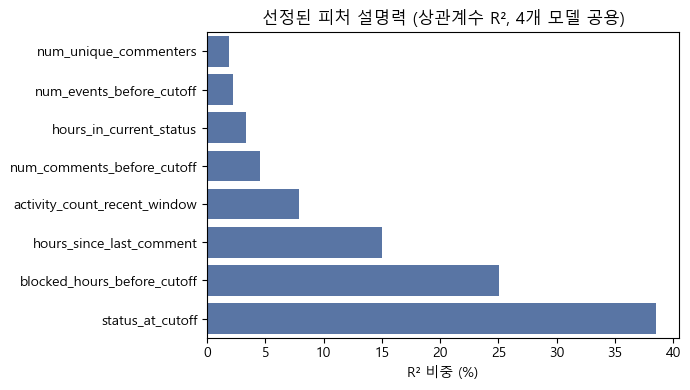

In [121]:
if _RUN_TRAINING_CELLS:
    # <선정된 피처 시각화 — 상관계수 R² 기준>
    print(f"\n선정된 피처 {len(selected_features)}개 설명 (R² 비중 내림차순):")
    selected_report = feature_importance_report[feature_importance_report["feature"].isin(selected_features)]
    for _, row in selected_report.iterrows():
        description = FEATURE_DESCRIPTIONS.get(row["feature"], "(설명 미등록)")
        print(f"  - {row['feature']} (R² 비중 {row['r2_pct']:.1f}%): {description}")

    plot_df = selected_report.sort_values("r2_pct")
    fig, ax = plt.subplots(figsize=(7, max(4, len(selected_features) * 0.35)))
    sns.barplot(data=plot_df, x="r2_pct", y="feature", color="#4C72B0", ax=ax)
    ax.set_xlabel("R² 비중 (%)")
    ax.set_ylabel("")
    ax.set_title("선정된 피처 설명력 (상관계수 R², 4개 모델 공용)")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


In [122]:
if _RUN_TRAINING_CELLS:
    # <학습/검증 데이터 - 층화 분할>
    # (제거된 기능) 예전 Jira 학습 데이터는 이슈 하나당 여러 시점(스냅샷 1/3/7/14/30일)을
    # 뽑아 여러 행을 만들었기 때문에, 같은 이슈의 스냅샷들이 train/valid 양쪽에 걸쳐
    # 들어가는 그룹 누수를 막으려고 issue_key 단위로 그룹째 배정하는
    # StratifiedGroupKFold를 썼다. 지금은 mock_issue_dataset.py가 업무(issue_key)당
    # 학습 행을 1개만 만들어(단일 시점) issue_key가 df에서 항상 유일하므로, 그룹 분할이
    # 더 이상 필요 없다 — risk_class 기준으로 행 단위 층화 분할만 하면 된다.
    # train.py가 `_TRAIN_TEST_SIZE`를 미리 넣어주면 그 값을 쓰고,
    # 노트북에서 직접 실행할 땐 0.2가 기본값.
    test_size = globals().get("_TRAIN_TEST_SIZE", 0.2)
    train_df, test_df = train_test_split(
        df, test_size=test_size, stratify=df["risk_class"], random_state=42
    )
    train_df = train_df.copy()
    test_df = test_df.copy()

    # <데이터 분할 결과 시각화>
    print(f"학습/검증 분할 완료 — train: {len(train_df)}행, valid: {len(test_df)}행")
    display(
        pd.DataFrame(
            {
                "train": train_df["risk_class"].value_counts().sort_index(),
                "valid": test_df["risk_class"].value_counts().sort_index(),
            }
        ).fillna(0).astype(int)
    )

    all_classes = set(df["risk_class"].unique())
    missing_in_train = all_classes - set(train_df["risk_class"].unique())
    missing_in_valid = all_classes - set(test_df["risk_class"].unique())
    if missing_in_train:
        logger.warning("train 세트에 없는 클래스: %s", missing_in_train)
    if missing_in_valid:
        logger.warning("valid 세트에 없는 클래스: %s", missing_in_valid)


학습/검증 분할 완료 — train: 3600행, valid: 900행


,train,valid
risk_class,,
0,1200,300
1,1200,300
2,1200,300


In [123]:
if _RUN_TRAINING_CELLS:
    # <컬럼을 딕셔너리 형태로 담음 — frequency_maps>
    # 실제 학습(train_df) 기준으로 만든 빈도 인코딩 딕셔너리.
    frequency_maps = {
        col: train_df[col].value_counts().to_dict()
        for col in FREQUENCY_ENCODED_COLUMNS
        if col in train_df.columns
    }
    print(f"빈도 인코딩 딕셔너리(frequency_maps) 생성 완료 — 대상 컬럼: {list(frequency_maps.keys())}")
    for col, mapping in frequency_maps.items():
        print(f"  · {col}: 고유값 {len(mapping)}개 (상위 5개: {dict(list(mapping.items())[:5])})")

    # train/valid 양쪽에 동일한 frequency_maps로 빈도 인코딩 + 범주형 dtype 적용.
    for target_df in (train_df, test_df):
        for col in FREQUENCY_ENCODED_COLUMNS:
            if col in target_df.columns:
                target_df[col] = target_df[col].map(frequency_maps.get(col, {})).fillna(0).astype(int)
        for col in CATEGORICAL_COLUMNS:
            if col in target_df.columns:
                target_df[col] = target_df[col].astype("category")


빈도 인코딩 딕셔너리(frequency_maps) 생성 완료 — 대상 컬럼: ['reporter', 'assignee_at_cutoff']
  · reporter: 고유값 1개 (상위 5개: {'unknown': 3600})
  · assignee_at_cutoff: 고유값 72개 (상위 5개: {'unassigned': 176, '1': 82, '66': 80, '71': 79, '69': 74})


In [124]:
if _RUN_TRAINING_CELLS:
    # 위에서 분할 이전 전체 데이터로 선정한 피처만 사용(피처 개수 축소).
    feature_names = [c for c in selected_features if c in train_df.columns]
    categorical_columns = [c for c in CATEGORICAL_COLUMNS if c in feature_names]

    # <사용 피처 + 타겟 결합 데이터프레임>
    # 실제 학습에 들어가는 피처(feature_names)와 타겟(risk_class)만 모아
    # 최종적으로 모델이 무엇을 보고 무엇을 맞추는지 한눈에 확인한다.
    print("<사용 피처 + 타겟 결합 데이터프레임>")
    display(df[feature_names + ["risk_class"]])


<사용 피처 + 타겟 결합 데이터프레임>


,status_at_cutoff,blocked_hours_before_cutoff,hours_since_last_comment,activity_count_recent_window,num_comments_before_cutoff,hours_in_current_status,num_events_before_cutoff,num_unique_commenters,risk_class
0,In Progress,0.000000,55.875990,4,15,1091.052941,20,7,0
1,Blocked,618.211452,299.252780,0,15,618.211452,20,7,1
2,In Progress,0.000000,130.424462,0,15,1050.442574,20,3,0
3,Blocked,1987.912143,70.391475,1,15,1987.912143,20,7,2
4,In Progress,0.000000,1452.259645,0,15,558.603562,16,5,1
...,...,...,...,...,...,...,...,...,...
4495,In Progress,0.000000,11.300099,2,1,5.765123,1,1,0
4496,In Progress,0.000000,4.898965,1,1,17.958992,0,1,0
4497,In Progress,0.000000,24.572178,1,0,13.133634,1,0,2
4498,In Progress,0.000000,24.488878,0,0,14.111465,0,0,2


In [125]:
if _RUN_TRAINING_CELLS:
    # <불균형 데이터 처리 - SMOTE기반 균형 샘플링>
    # 참고: https://jaylala.tistory.com/entry/불균형데이터처리-오버샘플링Oversampling-SMOTE
    #
    # 바로 아래(다음 셀)에서는 원래 lgb.Dataset에 역빈도 weight를 줘서 클래스 불균형
    # ('위험'/'주의' 표본이 '정상'보다 훨씬 적음)을 보정했었다. 여기서는 그 대신, 최종
    # 학습 세트(train_df)의 소수 클래스 "표본 자체"를 늘려서 균형을 맞추는 오버샘플링
    # (SMOTE)을 적용한다. 아래에서 만든 train_features_resampled/train_labels_resampled를
    # 다음 셀의 lgb.Dataset 생성에 그대로 사용한다(더 이상 weight는 쓰지 않는다).
    #
    # SMOTE 원리:
    #   1) 소수 클래스에 속한 표본 하나를 고른다.
    #   2) 같은 소수 클래스 안에서 그 표본의 k-최근접 이웃(KNN)을 찾는다.
    #   3) 표본과 이웃을 잇는 직선 위의 임의의 지점에 새로운 "합성" 표본을 만든다.
    #   => 원본을 그대로 복제(단순 중복)하는 게 아니라 새 값을 보간해서 만들기 때문에,
    #      단순 복제보다 모델이 소수 클래스를 외우기만 하는 과적합 위험이 적다.
    #
    # 왜 SMOTE가 아니라 SMOTENC인가:
    #   일반 SMOTE는 모든 피처가 연속형(숫자)이라고 가정하고 "두 값 사이를 보간"한다.
    #   하지만 우리 피처에는 issuetype_name/priority_name 같은 범주형(category) 컬럼이
    #   섞여 있어서, 이런 컬럼까지 숫자처럼 보간하면 존재하지도 않는 값이 생겨버린다.
    #   SMOTENC(SMOTE for Nominal and Continuous)는 연속형 피처는 SMOTE처럼 보간하고,
    #   범주형 피처는 이웃들의 값 중 하나를 그대로 가져오는 방식으로 처리해준다.
    #   그래서 어떤 컬럼이 범주형인지 인덱스로 알려줘야 한다.
    #

    # 학습 세트(train_df)에만 적용하고, 검증 세트(test_df)는 원본 분포 그대로 유지함:
    #   valid(test_df)는 "실제 운영에서 만날 데이터 분포"를 흉내내야 검증 점수를 믿을 수 있다.
    #   여기에 합성 표본이 섞이면 모델이 검증셋의 정보를 미리 엿본 것과 같은 효과(데이터 누수)가
    #   생겨 검증 점수가 실제보다 부풀려진다. 그래서 SMOTE는 train/valid를 나눈 "이후",
    #   train 쪽에만 적용한다.
    from imblearn.over_sampling import SMOTENC

    # feature_names 안에서 범주형 컬럼이 몇 번째 위치인지 인덱스로 변환 — SMOTENC는
    # 컬럼 이름이 아니라 인덱스(또는 불리언 마스크)로 범주형 위치를 지정받는다.
    categorical_feature_indices = [feature_names.index(c) for c in categorical_columns]

    # SMOTENC는 내부적으로 k-최근접 이웃 거리를 계산하므로 NaN을 다루지 못한다.
    # (예: 예상 소요시간이 없는 이슈는 progress_ratio_at_cutoff가 NaN — LightGBM은 이 NaN을
    # "결측치"로 그대로 학습에 활용하지만, SMOTENC에 넣기 전에는 임시로 0으로 채워야 한다.)
    # 범주형 컬럼은 0이 유효한 카테고리가 아닐 수 있으므로 숫자형 컬럼만 채운다.
    numeric_feature_names = [c for c in feature_names if c not in categorical_columns]
    train_features = train_df[feature_names].copy()
    train_features[numeric_feature_names] = train_features[numeric_feature_names].fillna(0)
    train_labels = train_df["risk_class"]

    print(f"SMOTE 적용 전 학습 세트 클래스 분포:\n{train_labels.value_counts().sort_index()}")

    # SMOTE의 기본 k_neighbors(5)는 "소수 클래스 표본 수 - 1"보다 클 수 없다(자기 자신을 뺀
    # 이웃 5개가 필요하므로 최소 6개 표본이 있어야 함). 표본이 아주 적은 경우를 대비해
    # k_neighbors를 소수 클래스 크기에 맞춰 동적으로 낮춘다.
    minority_class_count = train_labels.value_counts().min()
    if minority_class_count < 2:
        logger.warning(
            "소수 클래스 표본이 %d개뿐이라 SMOTE를 적용할 수 없어 원본 분포를 그대로 사용합니다.",
            minority_class_count,
        )
        train_features_resampled, train_labels_resampled = train_features, train_labels
    else:
        k_neighbors = min(5, minority_class_count - 1)
        smote = SMOTENC(
            categorical_features=categorical_feature_indices,
            k_neighbors=k_neighbors,
            random_state=42,
        )
        train_features_resampled, train_labels_resampled = smote.fit_resample(train_features, train_labels)

    print(f"\nSMOTE 적용 후 학습 세트 클래스 분포:\n{train_labels_resampled.value_counts().sort_index()}")
    print(f"학습 세트 행 수: {len(train_features)}행 -> {len(train_features_resampled)}행")


SMOTE 적용 전 학습 세트 클래스 분포:
risk_class
0    1200
1    1200
2    1200
Name: count, dtype: int64

SMOTE 적용 후 학습 세트 클래스 분포:
risk_class
0    1200
1    1200
2    1200
Name: count, dtype: int64
학습 세트 행 수: 3600행 -> 3600행


In [126]:
if _RUN_TRAINING_CELLS:
    # 클래스 불균형은 위 셀의 SMOTE 오버샘플링으로 이미 해결했으므로(train_labels_resampled는
    # 세 클래스가 균등하다), 역빈도 가중치(weight) 없이 그대로 학습에 사용한다.
    train_set = lgb.Dataset(
        train_features_resampled,
        label=train_labels_resampled,
        categorical_feature=categorical_columns,
    )
    valid_set = lgb.Dataset(
        test_df[feature_names],
        label=test_df["risk_class"],
        categorical_feature=categorical_columns,
        reference=train_set,
    )

    booster = lgb.train(
        {
            "objective": "multiclass",
            "num_class": NUM_CLASSES,
            "metric": ["multi_logloss", "multi_error"],
            "learning_rate": 0.05,
            "num_leaves": 31,
            "verbose": -1,
        },
        train_set,
        num_boost_round=500,
        valid_sets=[train_set, valid_set],
        valid_names=["train", "valid"],
        callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)],
    )


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[4]	train's multi_logloss: 0.880034	train's multi_error: 0.175	valid's multi_logloss: 0.893969	valid's multi_error: 0.213333


In [127]:
if _RUN_TRAINING_CELLS:
    # classification_report의 macro avg f1-score로 클래스별 불균형을 함께 확인한다.
    # F2-score는 recall을 더 크게 반영하므로, '주의'/'위험'을 놓치는 비용이 큰 지연 예측에서 함께 본다.
    # 혼동 행렬은 4개 모델을 한 번에 비교하는 "4개 모델 성능 비교" 섹션에서 그린다.
    probabilities = booster.predict(test_df[feature_names], num_iteration=booster.best_iteration)
    predicted_labels = np.argmax(probabilities, axis=1)

    class_labels = list(range(NUM_CLASSES))
    target_names = [RISK_CLASS_NAMES[i] for i in class_labels]
    validation_macro_f1_score = f1_score(
        test_df["risk_class"], predicted_labels, labels=class_labels, average="macro", zero_division=0
    )
    validation_macro_f2_score = fbeta_score(
        test_df["risk_class"], predicted_labels, beta=2, labels=class_labels, average="macro", zero_division=0
    )

    print(f"검증 macro avg f1-score: {validation_macro_f1_score:.4f}")
    print(f"검증 macro avg F2-score: {validation_macro_f2_score:.4f}")
    print(
        classification_report(
            test_df["risk_class"],
            predicted_labels,
            labels=class_labels,
            target_names=target_names,
            zero_division=0,
        )
    )


검증 macro avg f1-score: 0.7844
검증 macro avg F2-score: 0.7851
              precision    recall  f1-score   support

          정상       0.97      0.98      0.98       300
          주의       0.73      0.61      0.66       300
          위험       0.67      0.77      0.72       300

    accuracy                           0.79       900
   macro avg       0.79      0.79      0.78       900
weighted avg       0.79      0.79      0.78       900



In [128]:
if _RUN_TRAINING_CELLS:
    # <상수 정의 — CatBoost 하이퍼파라미터>
    # LightGBM과 같은 스케일의 베이스라인(튜닝 없음). iterations는 조기 종료 상한.
    CATBOOST_PARAMS = {
        "loss_function": "MultiClass",
        "classes_count": NUM_CLASSES,
        "learning_rate": 0.05,
        "depth": 6,
        "iterations": 500,
        "random_state": 42,
        "verbose": False,
        "allow_writing_files": False,
    }

    # <SMOTE 재사용>
    # feature_names/categorical_columns가 LightGBM과 완전히 동일(같은 selected_features,
    # 같은 category dtype 인코딩)하므로 SMOTE를 다시 돌리지 않고 위 LightGBM 섹션에서 만든
    # train_features_resampled/train_labels_resampled를 그대로 재사용한다.
    print(f"CatBoost 학습에 LightGBM과 동일한 SMOTE 결과 재사용 — {len(train_features_resampled)}행")


CatBoost 학습에 LightGBM과 동일한 SMOTE 결과 재사용 — 3600행


In [129]:
if _RUN_TRAINING_CELLS:
    # <모델 정의 및 학습 — CatBoost>
    cb_model = CatBoostClassifier(cat_features=categorical_columns, **CATBOOST_PARAMS)
    cb_model.fit(
        train_features_resampled,
        train_labels_resampled,
        eval_set=(test_df[feature_names], test_df["risk_class"]),
        early_stopping_rounds=30,
    )
    print(f"CatBoost 학습 완료 — best_iteration={cb_model.get_best_iteration()}")


CatBoost 학습 완료 — best_iteration=295


In [130]:
if _RUN_TRAINING_CELLS:
    # <상수 정의 — XGBoost 하이퍼파라미터>
    XGBOOST_PARAMS = {
        "objective": "multi:softprob",
        "num_class": NUM_CLASSES,
        "eval_metric": "mlogloss",
        "learning_rate": 0.05,
        "max_depth": 6,
        "n_estimators": 500,
        "tree_method": "hist",
        "enable_categorical": True,
        "random_state": 42,
    }

    # <SMOTE 재사용> — CatBoost와 같은 이유로 LightGBM의 결과를 그대로 쓴다.
    print(f"XGBoost 학습에 LightGBM과 동일한 SMOTE 결과 재사용 — {len(train_features_resampled)}행")


XGBoost 학습에 LightGBM과 동일한 SMOTE 결과 재사용 — 3600행


In [131]:
if _RUN_TRAINING_CELLS:
    # <모델 정의 및 학습 — XGBoost>
    xgb_model = XGBClassifier(**XGBOOST_PARAMS, early_stopping_rounds=30)
    xgb_model.fit(
        train_features_resampled,
        train_labels_resampled,
        eval_set=[(test_df[feature_names], test_df["risk_class"])],
        verbose=False,
    )
    print(f"XGBoost 학습 완료 — best_iteration={xgb_model.best_iteration}")


XGBoost 학습 완료 — best_iteration=106


In [132]:
if _RUN_TRAINING_CELLS:
    # <상수 정의 — RandomForest 하이퍼파라미터>
    # RandomForest는 조기 종료 개념이 없어 n_estimators를 고정값으로 둔다.
    RF_PARAMS = {
        "n_estimators": 500,
        "max_depth": None,
        "random_state": 42,
        "n_jobs": -1,
    }

    # <RandomForest 학습 입력 준비 — 명목형 원-핫 인코딩>
    # sklearn RandomForestClassifier는 범주형(category dtype)을 직접 못 받는다. 피처 "선정"은
    # 이미 위 공용 단계(상관계수 R²)에서 원본 컬럼 단위로 끝났으므로, 여기서는 선정된 피처 중
    # CATEGORICAL_COLUMNS만 원-핫으로 펼쳐 실제 학습 입력을 만든다.
    rf_nominal_columns = [c for c in categorical_columns if c in feature_names]
    rf_train_features = pd.get_dummies(train_df[feature_names], columns=rf_nominal_columns).fillna(0)
    rf_test_features = pd.get_dummies(test_df[feature_names], columns=rf_nominal_columns).fillna(0)
    # train/valid에 등장하는 카테고리 값이 다를 수 있어, test 쪽 더미 컬럼을 train 기준으로
    # 맞춘다(없는 컬럼은 0으로 채움) — 그래야 두 세트의 컬럼 구성이 모델 입력과 일치한다.
    rf_test_features = rf_test_features.reindex(columns=rf_train_features.columns, fill_value=0)

    print(
        f"RandomForest 원-핫 인코딩 완료 — 피처 {len(feature_names)}개 -> {rf_train_features.shape[1]}개 컬럼 "
        f"(명목형 {len(rf_nominal_columns)}개 컬럼 확장)"
    )


RandomForest 원-핫 인코딩 완료 — 피처 8개 -> 10개 컬럼 (명목형 1개 컬럼 확장)


In [133]:
if _RUN_TRAINING_CELLS:
    # <SMOTE 적용 — RandomForest는 일반 SMOTE 사용>
    # 원-핫 인코딩 후에는 진짜 "범주형 컬럼"이 없고 전부 numeric(0/1 포함)이다. SMOTENC로
    # 더미 컬럼 각각을 독립적으로 범주형 취급하면 원-핫의 "하나만 1" 제약이 깨질 수 있어
    # (이웃마다 다른 더미가 1로 선택될 수 있음), 일반 SMOTE로 전부 연속형처럼 보간한다.
    # 보간된 더미 값이 소수점이 되는 것은 알려진 근사이며 RandomForest 학습에는 문제 없다.
    from imblearn.over_sampling import SMOTE

    rf_train_labels = train_df["risk_class"]
    print(f"SMOTE 적용 전 학습 세트 클래스 분포:\n{rf_train_labels.value_counts().sort_index()}")

    rf_minority_class_count = rf_train_labels.value_counts().min()
    if rf_minority_class_count < 2:
        logger.warning(
            "소수 클래스 표본이 %d개뿐이라 SMOTE를 적용할 수 없어 원본 분포를 그대로 사용합니다.",
            rf_minority_class_count,
        )
        rf_train_features_resampled, rf_train_labels_resampled = rf_train_features, rf_train_labels
    else:
        rf_k_neighbors = min(5, rf_minority_class_count - 1)
        rf_smote = SMOTE(k_neighbors=rf_k_neighbors, random_state=42)
        rf_train_features_resampled, rf_train_labels_resampled = rf_smote.fit_resample(
            rf_train_features, rf_train_labels
        )

    print(f"\nSMOTE 적용 후 학습 세트 클래스 분포:\n{rf_train_labels_resampled.value_counts().sort_index()}")
    print(f"학습 세트 행 수: {len(rf_train_features)}행 -> {len(rf_train_features_resampled)}행")


SMOTE 적용 전 학습 세트 클래스 분포:
risk_class
0    1200
1    1200
2    1200
Name: count, dtype: int64

SMOTE 적용 후 학습 세트 클래스 분포:
risk_class
0    1200
1    1200
2    1200
Name: count, dtype: int64
학습 세트 행 수: 3600행 -> 3600행


In [134]:
if _RUN_TRAINING_CELLS:
    # <모델 정의 및 학습 — RandomForest>
    rf_model = RandomForestClassifier(**RF_PARAMS)
    rf_model.fit(rf_train_features_resampled, rf_train_labels_resampled)
    print(f"RandomForest 학습 완료 — n_estimators={rf_model.n_estimators}, 입력 컬럼 {rf_train_features_resampled.shape[1]}개")


RandomForest 학습 완료 — n_estimators=500, 입력 컬럼 10개


## 11. 4개 모델 성능 비교

In [135]:
if _RUN_TRAINING_CELLS:
    # <4개 모델 예측 수집>
    lgm_probabilities = booster.predict(test_df[feature_names], num_iteration=booster.best_iteration)
    lgm_predicted = np.argmax(lgm_probabilities, axis=1)
    cb_predicted = cb_model.predict(test_df[feature_names]).ravel().astype(int)
    xgb_predicted = xgb_model.predict(test_df[feature_names]).astype(int)
    rf_predicted = rf_model.predict(rf_test_features).astype(int)

    model_predictions = {
        "LightGBM": lgm_predicted,
        "CatBoost": cb_predicted,
        "XGBoost": xgb_predicted,
        "RandomForest": rf_predicted,
    }

    class_labels = list(range(NUM_CLASSES))
    target_names = [RISK_CLASS_NAMES[i] for i in class_labels]
    y_true = test_df["risk_class"]

    # <4개 모델 성능 비교 — precision/recall/f1-score/F2-score/support>
    comparison_rows = []
    validation_macro_f1_score_by_model = {}
    validation_macro_f2_score_by_model = {}
    for model_name, y_pred in model_predictions.items():
        report = classification_report(
            y_true, y_pred, labels=class_labels, target_names=target_names,
            zero_division=0, output_dict=True,
        )
        per_class_f2_scores = fbeta_score(
            y_true, y_pred, beta=2, labels=class_labels, average=None, zero_division=0
        )
        macro_f1_score = report["macro avg"]["f1-score"]
        macro_f2_score = fbeta_score(
            y_true, y_pred, beta=2, labels=class_labels, average="macro", zero_division=0
        )
        validation_macro_f1_score_by_model[model_name] = macro_f1_score
        validation_macro_f2_score_by_model[model_name] = macro_f2_score
        for class_name, class_f2_score in zip(target_names, per_class_f2_scores):
            comparison_rows.append({
                "model": model_name,
                "class": class_name,
                "precision": report[class_name]["precision"],
                "recall": report[class_name]["recall"],
                "f1-score": report[class_name]["f1-score"],
                "F2-score": class_f2_score,
                "support": report[class_name]["support"],
            })
        comparison_rows.append({
            "model": model_name,
            "class": "macro avg",
            "precision": report["macro avg"]["precision"],
            "recall": report["macro avg"]["recall"],
            "f1-score": macro_f1_score,
            "F2-score": macro_f2_score,
            "support": report["macro avg"]["support"],
        })

    comparison_report = pd.DataFrame(comparison_rows)
    print("<4개 모델 성능 비교 — 검증 precision/recall/f1-score/F2-score/support>")
    display(comparison_report)


<4개 모델 성능 비교 — 검증 precision/recall/f1-score/F2-score/support>


,model,class,precision,recall,f1-score,F2-score,support
0,LightGBM,정상,0.967213,0.983333,0.975207,0.980066,300.0
1,LightGBM,주의,0.728000,0.606667,0.661818,0.627586,300.0
2,LightGBM,위험,0.669565,0.770000,0.716279,0.747573,300.0
3,LightGBM,macro avg,0.788259,0.786667,0.784435,0.785075,900.0
4,CatBoost,정상,0.976744,0.980000,0.978369,0.979347,300.0
5,CatBoost,주의,0.689531,0.636667,0.662045,0.646581,300.0
6,CatBoost,위험,0.677019,0.726667,0.700965,0.716163,300.0
7,CatBoost,macro avg,0.781098,0.781111,0.780460,0.780697,900.0
8,XGBoost,정상,0.979798,0.970000,0.974874,0.971944,300.0
9,XGBoost,주의,0.670034,0.663333,0.666667,0.664663,300.0


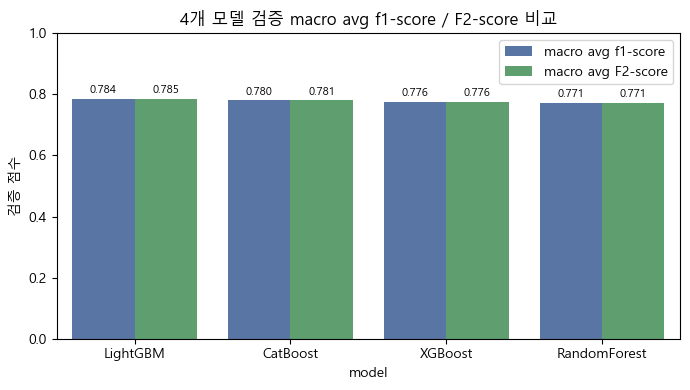

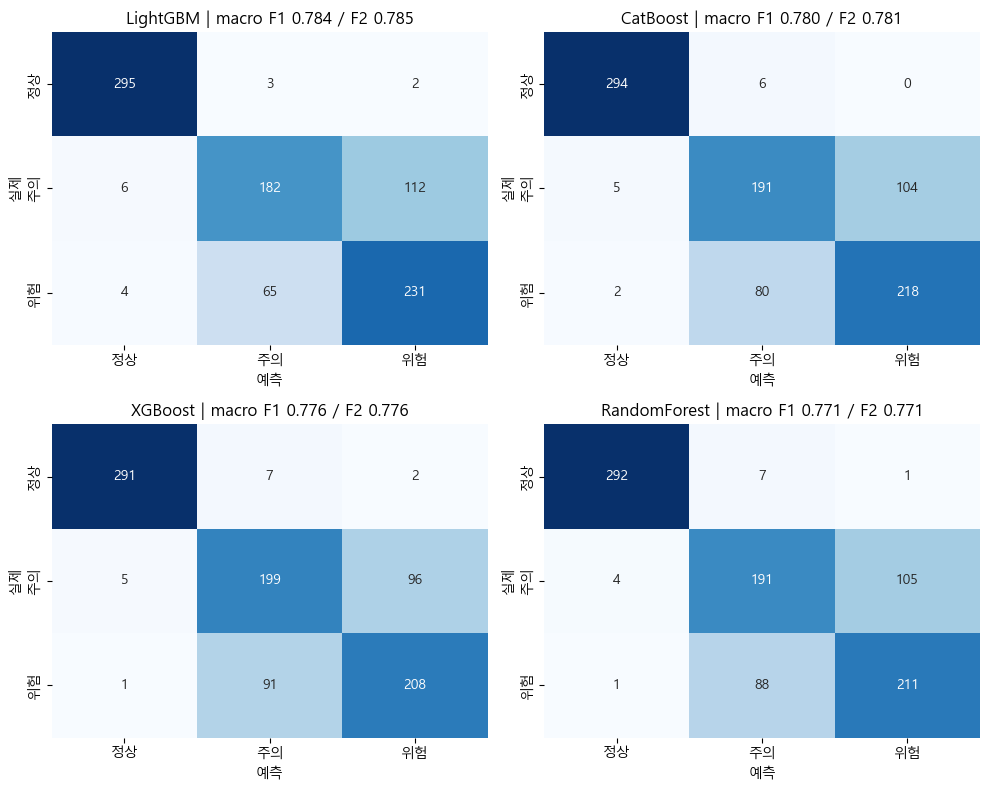

4개 모델 성능 비교 완료


In [136]:
if _RUN_TRAINING_CELLS:
    # <macro avg f1-score / F2-score 비교 막대그래프>
    model_order = list(validation_macro_f1_score_by_model.keys())
    metric_scores = pd.DataFrame(
        {
            "model": model_order,
            "macro avg f1-score": [validation_macro_f1_score_by_model[m] for m in model_order],
            "macro avg F2-score": [validation_macro_f2_score_by_model[m] for m in model_order],
        }
    ).melt(id_vars="model", var_name="metric", value_name="score")

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(
        data=metric_scores,
        x="model",
        y="score",
        hue="metric",
        palette=["#4C72B0", "#55A868"],
        ax=ax,
    )
    ax.set_ylabel("검증 점수")
    ax.set_ylim(0, 1)
    ax.set_title("4개 모델 검증 macro avg f1-score / F2-score 비교")
    ax.legend(title=None)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    # <혼동행렬 — 4개 모델 2x2 그리드>
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for ax, (model_name, y_pred) in zip(axes.flat, model_predictions.items()):
        cm = confusion_matrix(y_true, y_pred, labels=class_labels)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names, cbar=False, ax=ax,
        )
        ax.set_xlabel("예측")
        ax.set_ylabel("실제")
        ax.set_title(
            f"{model_name} | "
            f"macro F1 {validation_macro_f1_score_by_model[model_name]:.3f} / "
            f"F2 {validation_macro_f2_score_by_model[model_name]:.3f}"
        )
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    print("4개 모델 성능 비교 완료")


## 12. MLflow 하이퍼파라미터 튜닝 및 최적 모델 선정

4개 모델을 같은 train/valid 분할과 같은 검증 지표(`macro avg f1-score`)로 튜닝합니다. F2-score도
함께 계산해 각 trial의 파라미터와 검증 지표를 `App/backend_fastapi/mlruns/delay_risk` 아래 MLflow
file store에 기록합니다.


In [137]:
if _RUN_TRAINING_CELLS:
    # <MLflow 기반 하이퍼파라미터 튜닝>
    mlflow_tracking_dir = (BACKEND_FASTAPI_ROOT / "mlruns" / "delay_risk").resolve()
    mlflow_tracking_dir.mkdir(parents=True, exist_ok=True)
    os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
    mlflow.set_tracking_uri(mlflow_tracking_dir.as_uri())
    mlflow.set_experiment("delay-risk-hyperparameter-tuning")
    if mlflow.active_run() is not None:
        mlflow.end_run()

    print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

    tuning_records: list[dict[str, Any]] = []
    best_tuned_model: dict[str, Any] = {"macro_f1_score": -1.0}

    def _mlflow_param_value(value: Any) -> Any:
        return "None" if value is None else value

    def _record_candidate(
        *,
        model_name: str,
        model_type: str,
        trial_index: int,
        params: dict[str, Any],
        model: Any,
        predictions: np.ndarray,
        run_id: str,
        model_feature_columns: list[str] | None = None,
    ) -> dict[str, Any]:
        report = classification_report(
            y_true,
            predictions,
            labels=class_labels,
            target_names=target_names,
            zero_division=0,
            output_dict=True,
        )
        valid_macro_f1_score = report["macro avg"]["f1-score"]
        valid_macro_f2_score = fbeta_score(
            y_true, predictions, beta=2, labels=class_labels, average="macro", zero_division=0
        )
        mlflow.log_metric("valid_macro_f1_score", valid_macro_f1_score)
        mlflow.log_metric("valid_macro_f2_score", valid_macro_f2_score)
        # 기존 MLflow 조회와의 호환을 위해 유지하는 alias. 값은 macro avg f1-score와 같다.
        mlflow.log_metric("valid_f1_score", valid_macro_f1_score)
        mlflow.log_metric("valid_precision", report["macro avg"]["precision"])
        mlflow.log_metric("valid_recall", report["macro avg"]["recall"])

        record = {
            "model": model_name,
            "trial": trial_index,
            "macro avg f1-score": valid_macro_f1_score,
            "macro avg F2-score": valid_macro_f2_score,
            "precision": report["macro avg"]["precision"],
            "recall": report["macro avg"]["recall"],
            "run_id": run_id,
        }
        record.update(params)
        tuning_records.append(record)

        return {
            "model_name": model_name,
            "model_type": model_type,
            "trial": trial_index,
            "params": params,
            "model": model,
            "predictions": predictions,
            "macro_f1_score": valid_macro_f1_score,
            "macro_f2_score": valid_macro_f2_score,
            "run_id": run_id,
            "model_feature_columns": model_feature_columns,
        }

    def _select_better(current: dict[str, Any], candidate: dict[str, Any]) -> dict[str, Any]:
        if candidate["macro_f1_score"] > current.get("macro_f1_score", -1.0):
            return candidate
        return current

    LIGHTGBM_TUNING_GRID = [
        {"learning_rate": 0.03, "num_leaves": 31, "min_data_in_leaf": 20, "num_boost_round": 500},
        {"learning_rate": 0.05, "num_leaves": 63, "min_data_in_leaf": 10, "num_boost_round": 500},
        {"learning_rate": 0.08, "num_leaves": 31, "min_data_in_leaf": 10, "num_boost_round": 400},
    ]
    CATBOOST_TUNING_GRID = [
        {"learning_rate": 0.03, "depth": 4, "l2_leaf_reg": 3, "iterations": 500},
        {"learning_rate": 0.05, "depth": 6, "l2_leaf_reg": 3, "iterations": 500},
        {"learning_rate": 0.08, "depth": 6, "l2_leaf_reg": 5, "iterations": 400},
    ]
    XGBOOST_TUNING_GRID = [
        {"learning_rate": 0.03, "max_depth": 4, "n_estimators": 500, "subsample": 0.9, "colsample_bytree": 0.9},
        {"learning_rate": 0.05, "max_depth": 6, "n_estimators": 500, "subsample": 0.9, "colsample_bytree": 0.9},
        {"learning_rate": 0.08, "max_depth": 5, "n_estimators": 400, "subsample": 0.8, "colsample_bytree": 0.8},
    ]
    RF_TUNING_GRID = [
        {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
        {"n_estimators": 500, "max_depth": 12, "min_samples_leaf": 1, "max_features": "sqrt"},
        {"n_estimators": 500, "max_depth": None, "min_samples_leaf": 2, "max_features": "log2"},
    ]

    for trial_index, params in enumerate(LIGHTGBM_TUNING_GRID, start=1):
        with mlflow.start_run(run_name=f"LightGBM-{trial_index:02d}") as run:
            mlflow.set_tag("stage", "hyperparameter_tuning")
            mlflow.set_tag("model_name", "LightGBM")
            mlflow.log_param("model_name", "LightGBM")
            for key, value in params.items():
                mlflow.log_param(key, _mlflow_param_value(value))

            lgb_params = {
                "objective": "multiclass",
                "num_class": NUM_CLASSES,
                "metric": ["multi_logloss", "multi_error"],
                "verbose": -1,
                "feature_pre_filter": False,
                "learning_rate": params["learning_rate"],
                "num_leaves": params["num_leaves"],
                "min_data_in_leaf": params["min_data_in_leaf"],
            }
            trial_train_set = lgb.Dataset(
                train_features_resampled,
                label=train_labels_resampled,
                categorical_feature=categorical_columns,
                params={"feature_pre_filter": False},
            )
            trial_valid_set = lgb.Dataset(
                test_df[feature_names],
                label=test_df["risk_class"],
                categorical_feature=categorical_columns,
                reference=trial_train_set,
                params={"feature_pre_filter": False},
            )
            tuned_booster = lgb.train(
                lgb_params,
                trial_train_set,
                num_boost_round=params["num_boost_round"],
                valid_sets=[trial_valid_set],
                valid_names=["valid"],
                callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)],
            )
            predictions = np.argmax(
                tuned_booster.predict(test_df[feature_names], num_iteration=tuned_booster.best_iteration),
                axis=1,
            )
            candidate = _record_candidate(
                model_name="LightGBM",
                model_type="lightgbm",
                trial_index=trial_index,
                params=params,
                model=tuned_booster,
                predictions=predictions,
                run_id=run.info.run_id,
            )
            best_tuned_model = _select_better(best_tuned_model, candidate)

    for trial_index, params in enumerate(CATBOOST_TUNING_GRID, start=1):
        with mlflow.start_run(run_name=f"CatBoost-{trial_index:02d}") as run:
            mlflow.set_tag("stage", "hyperparameter_tuning")
            mlflow.set_tag("model_name", "CatBoost")
            mlflow.log_param("model_name", "CatBoost")
            for key, value in params.items():
                mlflow.log_param(key, _mlflow_param_value(value))

            tuned_cb_model = CatBoostClassifier(
                loss_function="MultiClass",
                classes_count=NUM_CLASSES,
                random_state=42,
                verbose=False,
                allow_writing_files=False,
                cat_features=categorical_columns,
                **params,
            )
            tuned_cb_model.fit(
                train_features_resampled,
                train_labels_resampled,
                eval_set=(test_df[feature_names], test_df["risk_class"]),
                early_stopping_rounds=30,
            )
            predictions = tuned_cb_model.predict(test_df[feature_names]).ravel().astype(int)
            candidate = _record_candidate(
                model_name="CatBoost",
                model_type="catboost",
                trial_index=trial_index,
                params=params,
                model=tuned_cb_model,
                predictions=predictions,
                run_id=run.info.run_id,
            )
            best_tuned_model = _select_better(best_tuned_model, candidate)

    for trial_index, params in enumerate(XGBOOST_TUNING_GRID, start=1):
        with mlflow.start_run(run_name=f"XGBoost-{trial_index:02d}") as run:
            mlflow.set_tag("stage", "hyperparameter_tuning")
            mlflow.set_tag("model_name", "XGBoost")
            mlflow.log_param("model_name", "XGBoost")
            for key, value in params.items():
                mlflow.log_param(key, _mlflow_param_value(value))

            tuned_xgb_model = XGBClassifier(
                objective="multi:softprob",
                num_class=NUM_CLASSES,
                eval_metric="mlogloss",
                tree_method="hist",
                enable_categorical=True,
                random_state=42,
                early_stopping_rounds=30,
                **params,
            )
            tuned_xgb_model.fit(
                train_features_resampled,
                train_labels_resampled,
                eval_set=[(test_df[feature_names], test_df["risk_class"])],
                verbose=False,
            )
            predictions = tuned_xgb_model.predict(test_df[feature_names]).astype(int)
            candidate = _record_candidate(
                model_name="XGBoost",
                model_type="xgboost",
                trial_index=trial_index,
                params=params,
                model=tuned_xgb_model,
                predictions=predictions,
                run_id=run.info.run_id,
            )
            best_tuned_model = _select_better(best_tuned_model, candidate)

    for trial_index, params in enumerate(RF_TUNING_GRID, start=1):
        with mlflow.start_run(run_name=f"RandomForest-{trial_index:02d}") as run:
            mlflow.set_tag("stage", "hyperparameter_tuning")
            mlflow.set_tag("model_name", "RandomForest")
            mlflow.log_param("model_name", "RandomForest")
            for key, value in params.items():
                mlflow.log_param(key, _mlflow_param_value(value))

            tuned_rf_model = RandomForestClassifier(random_state=42, n_jobs=-1, **params)
            tuned_rf_model.fit(rf_train_features_resampled, rf_train_labels_resampled)
            predictions = tuned_rf_model.predict(rf_test_features).astype(int)
            candidate = _record_candidate(
                model_name="RandomForest",
                model_type="random_forest",
                trial_index=trial_index,
                params=params,
                model=tuned_rf_model,
                predictions=predictions,
                run_id=run.info.run_id,
                model_feature_columns=list(rf_train_features.columns),
            )
            best_tuned_model = _select_better(best_tuned_model, candidate)

    tuning_results = pd.DataFrame(tuning_records).sort_values("macro avg f1-score", ascending=False).reset_index(drop=True)
    best_model_name = best_tuned_model["model_name"]
    best_model_type = best_tuned_model["model_type"]
    best_model = best_tuned_model["model"]
    best_model_predictions = best_tuned_model["predictions"]
    best_model_macro_f1_score = best_tuned_model["macro_f1_score"]
    best_model_macro_f2_score = best_tuned_model["macro_f2_score"]

    print("<MLflow 튜닝 결과 — 검증 macro avg f1-score 기준>")
    display(tuning_results)
    print(
        f"최적 모델: {best_model_name} (trial {best_tuned_model['trial']}, "
        f"macro avg f1-score={best_model_macro_f1_score:.4f}, "
        f"macro avg F2-score={best_model_macro_f2_score:.4f}, "
        f"run_id={best_tuned_model['run_id']})"
    )


MLflow tracking URI: file:///D:/AIproject/project/Team/work-flow/App/backend_fastapi/mlruns/delay_risk
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[8]	valid's multi_logloss: 0.865024	valid's multi_error: 0.215556
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[4]	valid's multi_logloss: 0.893156	valid's multi_error: 0.228889
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[8]	valid's multi_logloss: 0.640466	valid's multi_error: 0.207778
<MLflow 튜닝 결과 — 검증 macro avg f1-score 기준>


,model,trial,macro avg f1-score,macro avg F2-score,precision,recall,run_id,learning_rate,num_leaves,min_data_in_leaf,num_boost_round,depth,l2_leaf_reg,iterations,max_depth,n_estimators,subsample,colsample_bytree,min_samples_leaf,max_features
0,LightGBM,3,0.790687,0.790755,0.796408,0.792222,d3f2b65218ab48e9814c4b6f6243d3f2,0.08,31.0,10.0,400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CatBoost,1,0.782981,0.783128,0.783167,0.783333,478530d6d8be4b58bf0926e02509bd21,0.03,NaN,NaN,NaN,4.0,3.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN
2,XGBoost,2,0.782420,0.782281,0.782789,0.782222,7031091d3bf1417a846f6bb44bb7e2de,0.05,NaN,NaN,NaN,NaN,NaN,NaN,6.0,500.0,0.9,0.9,NaN,NaN
3,CatBoost,3,0.781625,0.781815,0.782440,0.782222,9173ba7b1cea445bb283940dfd447817,0.08,NaN,NaN,NaN,6.0,5.0,400.0,NaN,NaN,NaN,NaN,NaN,NaN
4,LightGBM,1,0.781539,0.782268,0.787506,0.784444,a12e355895cc4423b4f0fbaf3cf043e2,0.03,31.0,20.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,XGBoost,3,0.781414,0.781230,0.781736,0.781111,9b8f0a884416482ab9e3bbd4a1ca4155,0.08,NaN,NaN,NaN,NaN,NaN,NaN,5.0,400.0,0.8,0.8,NaN,NaN
6,RandomForest,3,0.780856,0.780881,0.781667,0.781111,b3dc6a3cc463487cb390170b61e40712,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0,NaN,NaN,2.0,log2
7,CatBoost,2,0.780460,0.780697,0.781098,0.781111,13f2e87bb5ba4430a5c946d1e51baa33,0.05,NaN,NaN,NaN,6.0,3.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN
8,RandomForest,2,0.777145,0.776853,0.777661,0.776667,5c08c39660fd42f1ac63ccd8b8daf3af,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,500.0,NaN,NaN,1.0,sqrt
9,XGBoost,1,0.772311,0.772245,0.772507,0.772222,f73ea744948e4dca92fbb9a445b801c8,0.03,NaN,NaN,NaN,NaN,NaN,NaN,4.0,500.0,0.9,0.9,NaN,NaN


최적 모델: LightGBM (trial 3, macro avg f1-score=0.7907, macro avg F2-score=0.7908, run_id=d3f2b65218ab48e9814c4b6f6243d3f2)


## 13. 최적 모델 저장

MLflow 튜닝 결과 검증 macro avg f1-score가 가장 높은 모델을 `delay_model.pkl`로 저장합니다.


In [138]:
if _RUN_TRAINING_CELLS:
    artifact = ModelArtifact(
        booster=best_model if best_model_type == "lightgbm" else None,
        feature_names=feature_names,
        categorical_columns=categorical_columns,
        frequency_maps=frequency_maps,
        proxy_deadline_map=proxy_deadline_map,
        global_median_duration_hours=global_median,
        model_type=best_model_type,
        model=best_model,
        model_feature_columns=best_tuned_model.get("model_feature_columns"),
        category_maps={
            col: list(train_df[col].cat.categories)
            for col in categorical_columns
            if hasattr(train_df[col], "cat")
        },
    )
    _save_artifact(artifact)
    print(f"최적 모델 저장 완료: {best_model_name} -> delay_model.pkl")


2026-07-20 20:00:06,786 [INFO] 모델 저장 완료: D:\AIproject\project\Team\work-flow\App\backend_fastapi\ml_delay_risk\models\delay_model.pkl


최적 모델 저장 완료: LightGBM -> delay_model.pkl


In [139]:
if _RUN_TRAINING_CELLS:
    # <학습 완료 후 생성된 ModelArtifact 객체 시각화>
    print(f"저장된 모델 유형: {artifact.model_type} ({best_model_name})")
    print(f"검증 macro avg f1-score: {best_model_macro_f1_score:.4f}")
    print(f"검증 macro avg F2-score: {best_model_macro_f2_score:.4f}")
    print(f"선정된 최종 피처 개수: {len(artifact.feature_names)}")
    display(artifact.feature_names)
    print(f"범주형 피처: {artifact.categorical_columns}")
    print(f"빈도 인코딩 대상 컬럼: {list(artifact.frequency_maps.keys())}")
    if artifact.model_feature_columns is not None:
        print(f"모델 입력 컬럼 수: {len(artifact.model_feature_columns)}")


저장된 모델 유형: lightgbm (LightGBM)
검증 macro avg f1-score: 0.7907
검증 macro avg F2-score: 0.7908
선정된 최종 피처 개수: 8


['status_at_cutoff',
 'blocked_hours_before_cutoff',
 'hours_since_last_comment',
 'activity_count_recent_window',
 'num_comments_before_cutoff',
 'hours_in_current_status',
 'num_events_before_cutoff',
 'num_unique_commenters']

범주형 피처: ['status_at_cutoff']
빈도 인코딩 대상 컬럼: ['reporter', 'assignee_at_cutoff']


## 14. 저장된 최적 모델로 추론 테스트 및 혼동 행렬


In [140]:
# 이 노트북 안에서는 load_artifact()가 이 노트북 자체의 전역변수 _artifact_cache를 참조하므로
# 방금 학습한 artifact를 바로 캐시에 넣어 재학습 없이 재사용할 수 있습니다.
if _RUN_TRAINING_CELLS:
    _artifact_cache = artifact

    # 테스트용 데이터
    sample_index = min(99, len(df) - 1)  ## 데이터가 충분하면 그대로 99번 행을 쓰고, 부족하면 마지막 행을 씁니다.
    sample_row = df.drop(columns=["risk_class", "created", "issue_key"]).iloc[sample_index]
    display(sample_row)


project_key                                 P10
issuetype_name                            other
priority_name                            medium
reporter                                unknown
is_subtask                                False
has_parent                                False
parent_unresolved                         False
num_subtasks                                  8
num_unresolved_subtasks                       4
num_components                                0
num_fixversions                               0
has_released_fixversion                   False
num_versions                                  0
has_original_estimate                     False
original_estimate_seconds                     0
num_issuelinks_total                          0
num_blocked_by_links                          0
num_unresolved_blockers                       0
created_day_of_week                           2
created_hour                                  0
summary_length                          

정상    0.470142
주의    0.205549
위험    0.324309
Name: 확률, dtype: float64

예측 클래스: 정상 (확률 0.4701)
<최적 모델 혼동 행렬>


,정상,주의,위험
정상,293,5,2
주의,3,183,114
위험,3,60,237


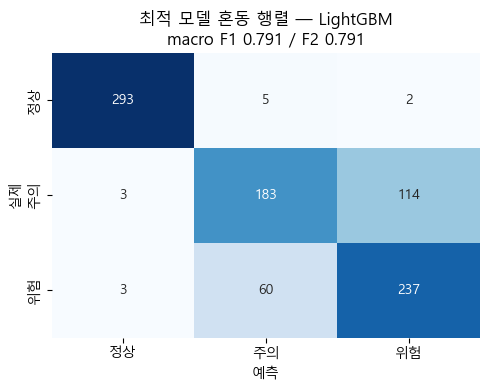

In [141]:
if _RUN_TRAINING_CELLS:
    # '지연 위험도 예측' 테스트 실행
    probabilities = predict_class_probabilities(sample_row.to_dict())
    class_probabilities = dict(zip(["정상", "주의", "위험"], probabilities))
    display(pd.Series(class_probabilities, name="확률"))

    predicted_class = max(class_probabilities, key=class_probabilities.get)
    print(f"예측 클래스: {predicted_class} (확률 {class_probabilities[predicted_class]:.4f})")

    # <최적 모델 혼동 행렬>
    best_cm = confusion_matrix(y_true, best_model_predictions, labels=class_labels)
    best_cm_df = pd.DataFrame(best_cm, index=target_names, columns=target_names)
    print("<최적 모델 혼동 행렬>")
    display(best_cm_df)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        best_cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names,
        cbar=False,
        ax=ax,
    )
    ax.set_xlabel("예측")
    ax.set_ylabel("실제")
    ax.set_title(
        f"최적 모델 혼동 행렬 — {best_model_name}\n"
        f"macro F1 {best_model_macro_f1_score:.3f} / F2 {best_model_macro_f2_score:.3f}"
    )
    fig.tight_layout()
    plt.show()
    plt.close(fig)
